# dupuis2023 — Dupuis et al. (2023) — Data-Dependent Fractal Dimensions

Same scaling law as Birdal but with a loss-difference distance metric — more sensitive to flat minima.


## What the paper does

Refines Birdal's idea with a **data-dependent** metric. Instead of Euclidean distance between weight iterates, the trajectory points are compared by their **loss difference** `|L(W_i) − L(W_j)|`, and the same `H0`-lifetime scaling law gives a PH dimension. This makes the dimension sensitive to the *flatness* of the minimum, not just the geometry of the path.

**Methodology:** weight trajectory + per-step losses → loss-difference distance → `H0` PH scaling → data-dependent PH dimension.

**Expected result:** the loss-difference PH dimension yields **tighter** generalisation bounds than the Euclidean version, especially in the flat-minimum regime.

> Like Birdal, this needs a **long** trajectory for the scaling fit, so we snapshot every iteration over ~30 epochs.


## Dataset & model in the paper

- **arXiv:** [https://arxiv.org/abs/2302.02766](https://arxiv.org/abs/2302.02766)
- **Venue:** ICML 2023
- **Datasets used:** CIFAR-10 (+ CIFAR-100 in the supplement).
- **Models used:** ResNet / AlexNet / VGG.  Here: SmallCNN — same loss-difference methodology, smaller scale.
- **Headline result to aim for:** Loss-difference PH dim gives tighter generalisation bounds than the Euclidean PH dim, especially in the flat-minimum regime.
- **Reference code:** [https://github.com/benjiDupuis/data_dependent_dimensions](https://github.com/benjiDupuis/data_dependent_dimensions)

To reproduce paper numbers, replace the synthetic-data cell below with the real model snapshot / activations / trajectory.  Everything else in the notebook stays the same.


**This notebook now runs on real data.**  A tiny model is trained briefly on the local dataset cache under `data/`.  Headline numbers won't match the paper (that needs full training on GPU); the *qualitative* behaviour the paper reports should still appear.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # make `paper_reproduce` importable
import numpy as np
import matplotlib.pyplot as plt
import torch
from tanc import TDAPipeline
from paper_reproduce._torch_setup import (
    load_mnist, load_fashion_mnist, load_cifar10, load_cifar100,
    SmallMLP, SmallCNN, CNN_FCN, train_briefly, extract_snapshot, pick_device,
)
np.random.seed(0); torch.manual_seed(0)
DEVICE = pick_device()                      # 'cuda' → 'mps' (Apple GPU) → 'cpu'


## 1. Load dataset + train a small model briefly


In [2]:
from tanc.model_extractor import TrainingExtractor

X_tr, y_tr = load_cifar10('train', n_samples=1500)
X_te, y_te = load_cifar10('test',  n_samples=400)
model = SmallCNN(in_channels=3, num_classes=10, width=8)

# Long per-iteration trajectory for the loss-difference scaling fit.
ext = TrainingExtractor(
    model=model,
    train_data=(X_tr, y_tr), batch_size=64,
    criterion=torch.nn.CrossEntropyLoss(),
    optimizer=torch.optim.Adam(model.parameters(), lr=1e-3),
    val_data=(X_te, y_te), extract_data=X_te[:64],
    aspects=['weights'],
    snapshot_every=1, snapshot_schedule='iteration',
    device=DEVICE, clarify=False,
)
view = ext.run(epochs=30, target_accuracy=None, verbose=False)
print(f'trajectory length: {len(view)} snapshots; '
      f'loss[0]={view.losses()[0]:.4f} -> loss[-1]={view.losses()[-1]:.4f}')


/var/folders/n_/d6k9fkh5225_g_fllx8zf2000000gp/T/ipykernel_58996/1539583829.py:8: UserWarning: Model 'Sequential' has both fully-connected (linear / SoRO) and conv layers. Defaulting to the fully-connected layers. Pass layer_selection='all_linear', 'all_conv', 'soro', 'linear_and_conv', 'all', or a list of names/indices to suppress this warning.
  ext = TrainingExtractor(


trajectory length: 720 snapshots; loss[0]=2.2992 -> loss[-1]=1.0756


## 2. Reproduce via `TDAPipeline.from_paper` — model-first

We hand the trained model object straight to the pipeline: `from_paper` already knows what this paper needs, and the pipeline's model-adapter extracts it for us — no manual feature pulling required.


In [3]:
pipe = TDAPipeline.from_paper("dupuis2023")
pipe.explain()


TDAPipeline — Dupuis et al. (2023)
  Stage 1: (skipped — direct dimension estimation)
  Stage 2: tool    = dimension
             method = 'ph_loss'
             estimator = 'trajectory_dimension'
             alpha = 1.0
  Default plot   : .plot('ph_scaling')


"TDAPipeline — Dupuis et al. (2023)\n  Stage 1: (skipped — direct dimension estimation)\n  Stage 2: tool    = dimension\n             method = 'ph_loss'\n             estimator = 'trajectory_dimension'\n             alpha = 1.0\n  Default plot   : .plot('ph_scaling')"

TopoResult(tool='dimension')
  paper       : Dupuis et al. (2023)
  data        : dimension_result (method=ph_dimension, dim=1.033)
  plots       :
    .plot('ph_scaling') — Log-log lifetime-sum vs subset size with regression.
  config keys : method


tanc/pipeline/pipeline.py:377: UserWarning: distance='loss_difference' received a 1-D (per-step) loss vector, so the distance is |mean-loss_i - mean-loss_j| — NOT the Dupuis et al. per-sample pseudo-metric mean_s|ell_i,s - ell_j,s|.  Pass a (T, n_samples) per-sample loss matrix for the paper-faithful metric.
  bundle = build_weight_trajectory(data, distance=distance,


"TopoResult(tool='dimension')\n  paper       : Dupuis et al. (2023)\n  data        : dimension_result (method=ph_dimension, dim=1.033)\n  plots       :\n    .plot('ph_scaling') — Log-log lifetime-sum vs subset size with regression.\n  config keys : method"

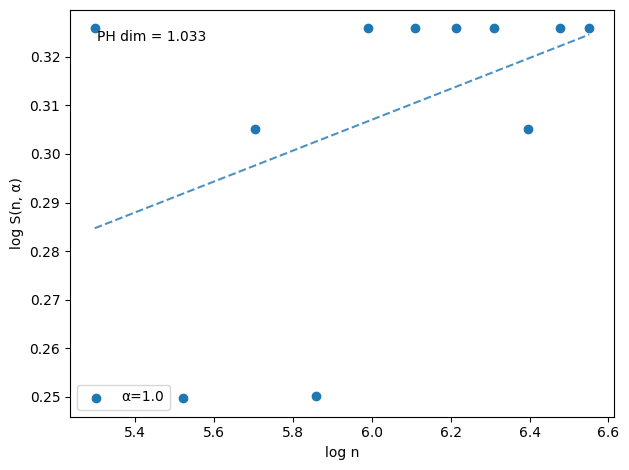

In [4]:
result, fig = pipe.reproduce(view)
result.describe()


## 3. Paper-specific follow-up plot


PH dimension (loss-difference): 1.032905216346587


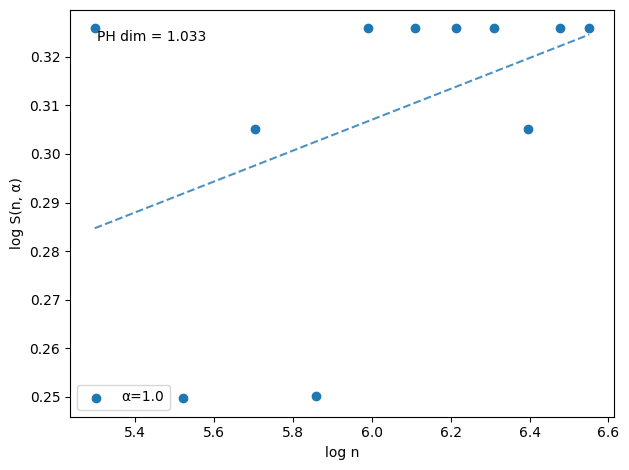

In [5]:
fig = result.plot("ph_scaling")
print('PH dimension (loss-difference):', result.dimension)


## Notes & gaps

* Implements the method as described, on a real loss-difference trajectory, fed **model-first**: passing the `TrainingView` lets the pipeline extract both the weight trajectory and the per-step losses for the `ph_loss` metric with no extra wiring.


## Deviations from the paper

Everything this notebook does differently from the source, and why. An empty
table below means the construction follows the paper as written — that is a
claim, not an omission. Scale always differs; see the last row.

| aspect | the paper | this notebook | why it matters |
|---|---|---|---|
| trajectory length | long SGD trajectories | a few hundred snapshots | same caveat as birdal2021: the estimate sits near the degenerate limit |
| scale | the paper's full experimental setup | a smaller model, fewer samples, fewer epochs | to keep the notebook runnable in minutes; expect weaker effects than published |
